In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
gps = pd.read_csv("dataset/gps.csv")
outcomes = pd.read_csv("dataset/loan_outcomes_train.csv")

In [7]:
# merge on user_id
df = gps.merge(
    outcomes,
    on="user_id",
    how="inner"
)

print("Merged rows:", len(df))

Merged rows: 69732


In [ ]:
df_clean = (
    df
    .dropna(subset=["latitude", "longitude", "user_id", "is_repaid"])
    .drop_duplicates(
        subset=["user_id", "latitude", "longitude"],
        keep="first"
    )
)

print("After deduplication:", len(df_clean))

After deduplication: 44447


In [9]:
repayers = df_clean[df_clean["is_repaid"] == True]
non_repayers = df_clean[df_clean["is_repaid"] == False]

print("Repayers:", len(repayers))
print("Non-Repayers:", len(non_repayers))

Repayers: 16321
Non-Repayers: 28126


In [ ]:
# viz on world map
def plot_class(df, title, color):
    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.scatter(
        df["longitude"],
        df["latitude"],
        s=6,
        alpha=0.4,
        color=color,
        transform=ccrs.PlateCarree()
    )

    plt.title(title)
    plt.show()


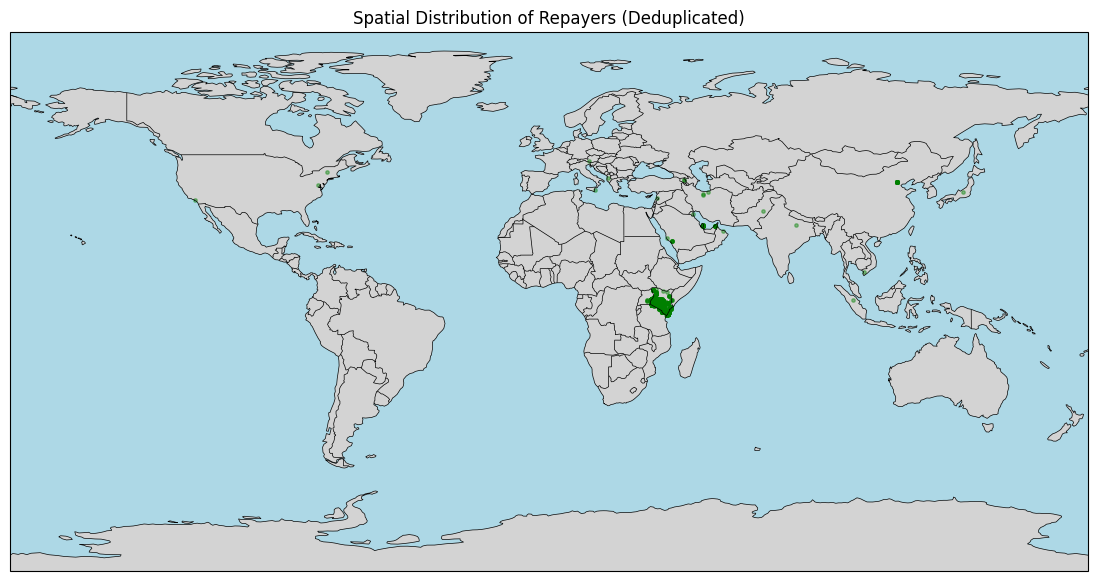

In [11]:
plot_class(
    repayers,
    "Spatial Distribution of Repayers (Deduplicated)",
    color="green"
)

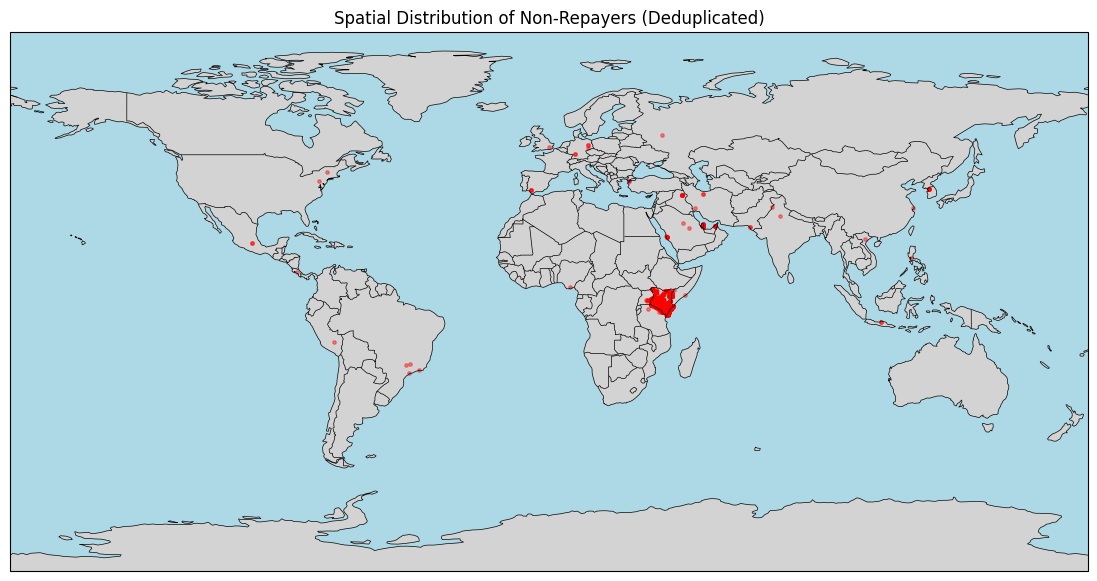

In [13]:
plot_class(
    non_repayers,
    "Spatial Distribution of Non-Repayers (Deduplicated)",
    color="red"
)


### Vizualisation using Hexbins (Binning)

In [ ]:
def plot_density_hexbin(df, title, cmap):
    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    hb = ax.hexbin(
        df["longitude"],
        df["latitude"],
        gridsize=80,              # controls resolution
        cmap=cmap,
        mincnt=1,
        transform=ccrs.PlateCarree()
    )

    plt.colorbar(hb, ax=ax, label="Point Density")
    plt.title(title)
    plt.show()


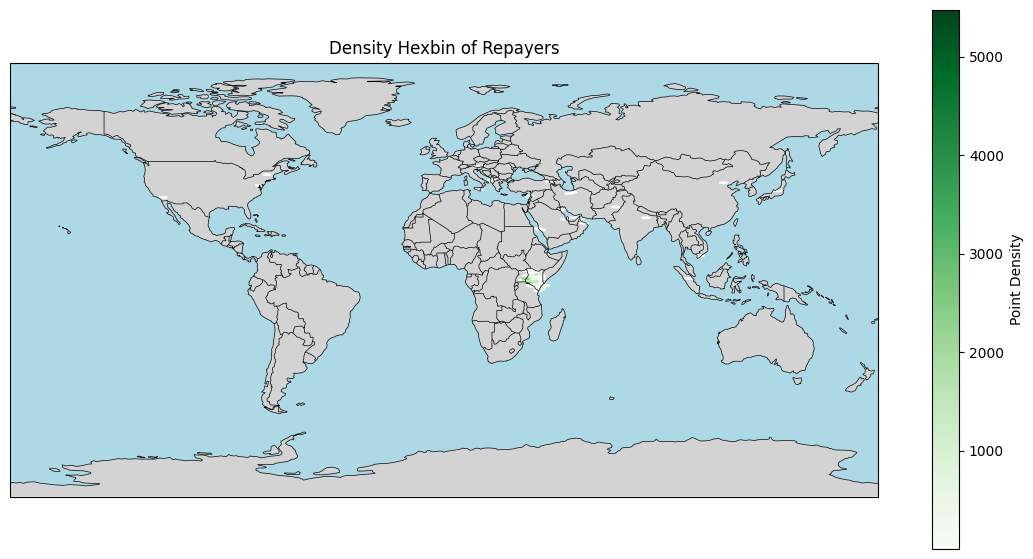

In [15]:
plot_density_hexbin(
    repayers,
    "Density Hexbin of Repayers",
    cmap="Greens")

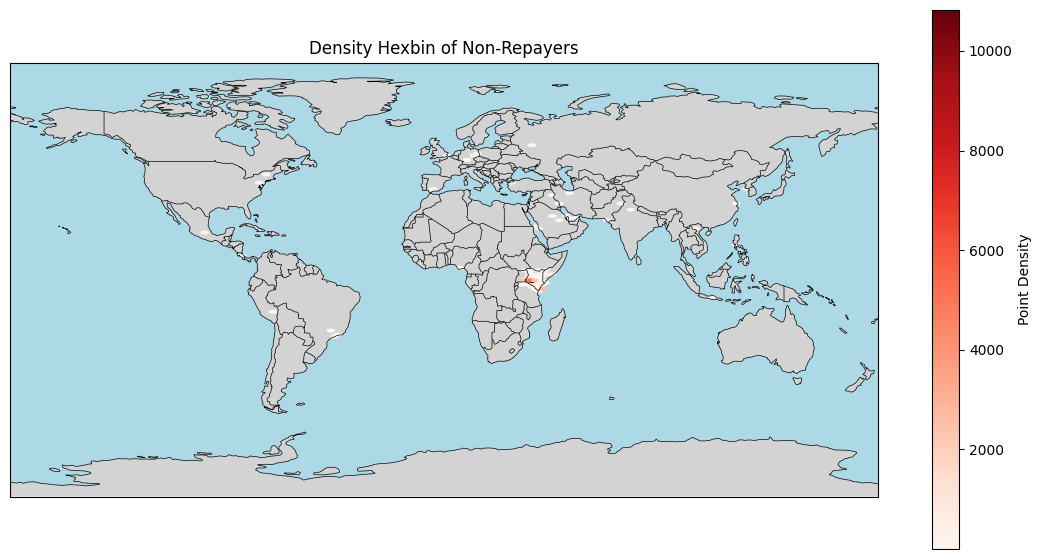

In [16]:
plot_density_hexbin(
    non_repayers,
    "Density Hexbin of Non-Repayers",
    cmap="Reds")

### Focusing on Kenya because of density being highest

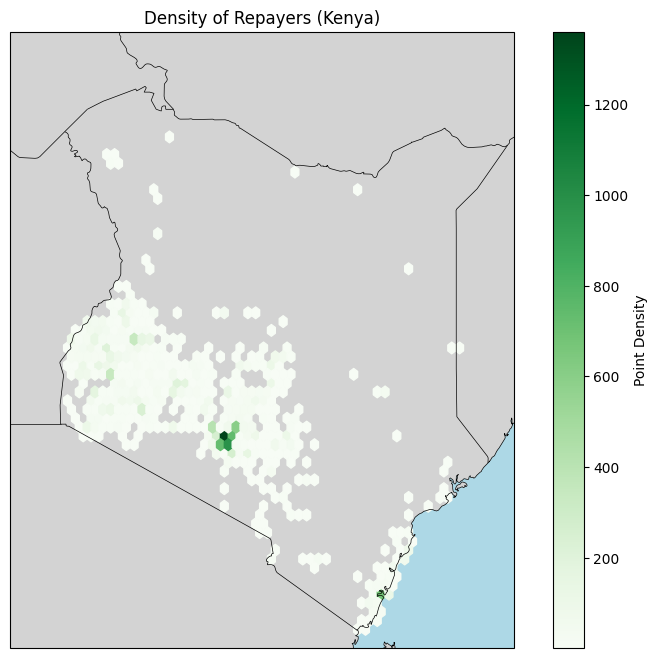

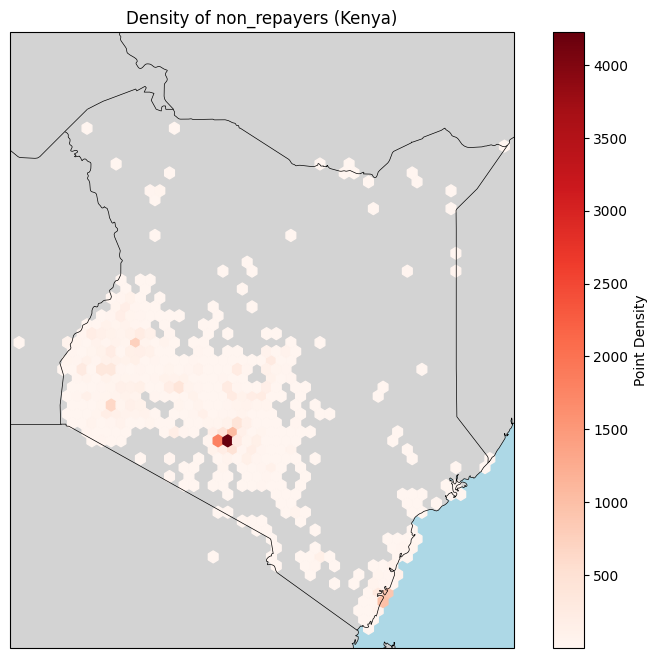

In [ ]:
# Kenya lat and long bounds
LONG_MIN, LONG_MAX = 33, 42
LAT_MIN, LAT_MAX = -5, 6

# --- filter to Kenya region ---
repayers_ke = repayers[
    (repayers["longitude"] >= LONG_MIN) &
    (repayers["longitude"] <= LONG_MAX) &
    (repayers["latitude"] >= LAT_MIN) &
    (repayers["latitude"] <= LAT_MAX)
]

non_repayers_ke = non_repayers[
    (non_repayers["longitude"] >= LONG_MIN) &
    (non_repayers["longitude"] <= LONG_MAX) &
    (non_repayers["latitude"] >= LAT_MIN) &
    (non_repayers["latitude"] <= LAT_MAX)
]

# repayers density plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([LONG_MIN, LONG_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

hb = ax.hexbin(
    repayers_ke["longitude"],
    repayers_ke["latitude"],
    gridsize=50,
    cmap="Greens",
    mincnt=1,
    transform=ccrs.PlateCarree()
)

plt.colorbar(hb, ax=ax, label="Point Density")
plt.title("Density of Repayers (Kenya)")
plt.show()

# non-repayers density plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([LONG_MIN, LONG_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

hb = ax.hexbin(
    non_repayers_ke["longitude"],
    non_repayers_ke["latitude"],
    gridsize=50,
    cmap="Reds",
    mincnt=1,
    transform=ccrs.PlateCarree()
)

plt.colorbar(hb, ax=ax, label="Point Density")
plt.title("Density of non_repayers (Kenya)")
plt.show()


### Similar but normalised differences map between repayers(blue) and non-repayers(red)

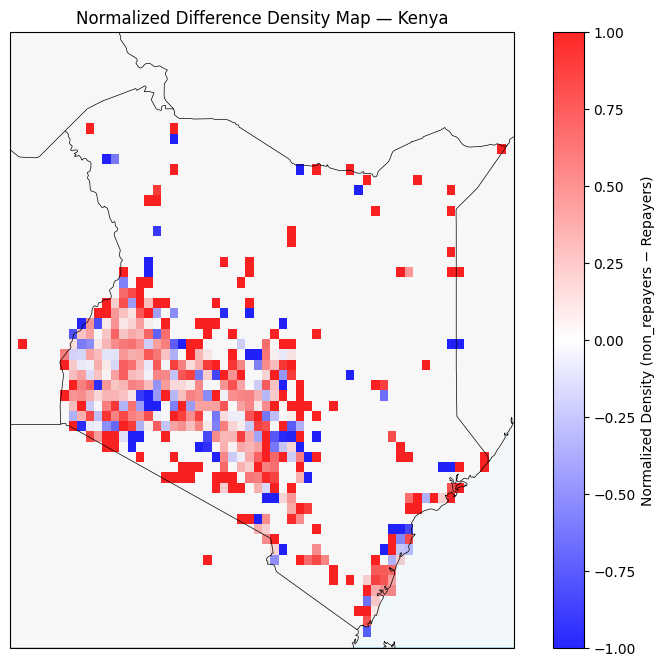

In [23]:
# Kenya lat, long
LONG_MIN, LONG_MAX = 33, 42
LAT_MIN, LAT_MAX = -5, 6

# --- filter to Kenya ---
rep_ke = repayers[
    (repayers["longitude"] >= LONG_MIN) &
    (repayers["longitude"] <= LONG_MAX) &
    (repayers["latitude"] >= LAT_MIN) &
    (repayers["latitude"] <= LAT_MAX)
]

non_rep_ke = non_repayers[
    (non_repayers["longitude"] >= LONG_MIN) &
    (non_repayers["longitude"] <= LONG_MAX) &
    (non_repayers["latitude"] >= LAT_MIN) &
    (non_repayers["latitude"] <= LAT_MAX)
]

bins = 60

rep_hist, xedges, yedges = np.histogram2d(
    rep_ke["longitude"],
    rep_ke["latitude"],
    bins=bins,
    range=[[LONG_MIN, LONG_MAX], [LAT_MIN, LAT_MAX]]
)

non_rep_hist, _, _ = np.histogram2d(
    non_rep_ke["longitude"],
    non_rep_ke["latitude"],
    bins=bins,
    range=[[LONG_MIN, LONG_MAX], [LAT_MIN, LAT_MAX]]
)

# --- normalized difference ---
eps = 1e-6  # avoid divide-by-zero
norm_diff = (non_rep_hist - rep_hist) / (non_rep_hist + rep_hist + eps)

# --- plot ---
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([LONG_MIN, LONG_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

im = ax.imshow(
    norm_diff.T,
    extent=[LONG_MIN, LONG_MAX, LAT_MIN, LAT_MAX],
    origin="lower",
    cmap="bwr",
    vmin=-1,
    vmax=1,
    alpha=0.85,
    transform=ccrs.PlateCarree()
)

plt.colorbar(im, ax=ax, label="Normalized Density (non_repayers − Repayers)")
plt.title("Normalized Difference Density Map — Kenya")
plt.show()


In [24]:
bins = 60
LONG_MIN, LONG_MAX = 33, 42
LAT_MIN, LAT_MAX = -5, 6

# gps points (optionally deduplicated per user/location)
gps_use = gps[
    (gps["longitude"] >= LONG_MIN) &
    (gps["longitude"] <= LONG_MAX) &
    (gps["latitude"] >= LAT_MIN) &
    (gps["latitude"] <= LAT_MAX)
].copy()

gps_use["long_bin"] = np.digitize(gps_use["longitude"], xedges) - 1
gps_use["lat_bin"] = np.digitize(gps_use["latitude"], yedges) - 1

# keep valid bins only
valid = (
    (gps_use["long_bin"] >= 0) & (gps_use["long_bin"] < bins) &
    (gps_use["lat_bin"] >= 0) & (gps_use["lat_bin"] < bins)
)
gps_use = gps_use[valid]

# lookup normalized risk value
gps_use["spatial_risk"] = norm_diff[
    gps_use["long_bin"],
    gps_use["lat_bin"]
]

# aggregate to user-level feature
user_spatial_feature = (
    gps_use
    .groupby("user_id")
    .agg(
        mean_spatial_risk=("spatial_risk", "mean"),
        max_spatial_risk=("spatial_risk", "max"),
        risk_variance=("spatial_risk", "var"),
        gps_points=("spatial_risk", "count")
    )
    .reset_index()
)

user_spatial_feature.head()


,user_id,mean_spatial_risk,max_spatial_risk,risk_variance,gps_points
0,1,0.606300,0.624365,0.000653,2
1,4,0.555556,0.555556,NaN,1
2,5,0.555556,0.555556,NaN,1
3,7,0.306756,0.308824,0.000017,4
4,8,0.564246,0.564246,NaN,1
